# ECON 5200 Consulting Report — Final Project
## Does 401(k) Eligibility Cause Workers to Save More?

| Field | Detail |
|-------|--------|
| **Client** | National Benefits Consulting Group |
| **Strategy** | Double Machine Learning (DML) |
| **Data** | Survey of Income and Program Participation (SIPP), 1991 |
| **Author** | Umang Rayamajhi |
| **Date** | 24/04/2026 |

---

---
##  Setup

In [ ]:
# Core
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Install econml if not already installed
!pip install econml

# ML / Causal ML
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import r2_score, mean_squared_error
from econml.dml import LinearDML
import statsmodels.api as sm


# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Plot style
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')

print('Setup complete.')

Setup complete.


---
##Data + Identification Strategy

### Research Design

| Element | Detail |
|---------|--------|
| **Research question** | Does 401(k) eligibility *cause* an increase in net financial assets? |
| **Data** | SIPP 1991 wave via `econml.datasets.fetch_401K`; n ≈ 9,915 |
| **Identification strategy** | Double Machine Learning (DML) — Chernozhukov et al. (2018, *Econometrica*) |
| **Key assumption** | **CIA**: after conditioning on age, income, education, family size, marital status, two-earner status, and IRA participation, 401(k) eligibility is as good as random |
| **Treatment variable** | `e401` — binary indicator for 401(k) eligibility (firm offers a plan) |
| **Outcome variable** | `net_tfa` — net total financial assets (\$) |
| **Controls (W)** | `age`, `inc`, `fsize`, `educ`, `married`, `two_earner`, `pira` |
| **Why prediction alone is insufficient** | A predictive model's feature importance for `e401` conflates the causal effect with selection. It cannot answer "what would happen if we *changed* eligibility?" — only "which workers *happen to have* high savings?" |

### How Double ML Works

DML removes non-linear confounding in three steps:

1. **Residualize the outcome:** Fit $\hat{Y} = m(W)$ with ML; compute $\tilde{Y} = Y - \hat{Y}$
2. **Residualize the treatment:** Fit $\hat{T} = g(W)$ with ML; compute $\tilde{T} = T - \hat{T}$
3. **Causal regression:** Regress $\tilde{Y}$ on $\tilde{T}$ → the coefficient is the ATE

Cross-fitting (5-fold) prevents overfitting bias from the nuisance models from contaminating the causal estimate. The resulting estimator is $\sqrt{n}$-consistent and asymptotically normal even when the ML models converge slowly.

In [ ]:
# ─── Data Loading ──────────────────────────────────────────────────────────────
# Using a direct URL for the 401K dataset as econml.datasets.fetch_401K is problematic.
# Loading from a stable public repository.
#df = pd.read_csv("https://raw.githubusercontent.com/skranz/causality/master/401k.csv")
# Install if needed (run this once, then restart runtime)
!pip install econml -q

# Core
import pandas as pd

!pip install doubleml -q

from doubleml.datasets import fetch_401K
import pandas as pd

data = fetch_401K()
df = data.data   # extract the DataFrame

print(df.shape)
df.head()

# The original fetch_401K returned a Bunch object which needed unpacking. Direct CSV load returns a DataFrame.
# The 'if hasattr(df, 'data'): df = df.data' block is no longer needed with direct CSV load.


# ─── Variable Map ──────────────────────────────────────────────────────────────
#   e401       — eligible for 401(k)             [TREATMENT]
#   net_tfa    — net total financial assets ($)  [OUTCOME]
#   p401       — participates in 401(k)          [POST-TREATMENT: do NOT use as W]
#   age        — age in years
#   inc        — annual income ($)
#   fsize      — family size
#   educ        — years of education
#   married    — married indicator
#   two_earner — two-earner household indicator
#   pira       — IRA participation               [see Threats section: may be endogenous]

TREATMENT = 'e401'
OUTCOME   = 'net_tfa'
CONTROLS  = ['age', 'inc', 'fsize', 'educ', 'marr', 'twoearn', 'pira'] # Corrected column names

print(f"Dataset shape:             {df.shape}")
print(f"Treatment prevalence:      {df[TREATMENT].mean():.1%} eligible")
print(f"Mean outcome (all):        ${df[OUTCOME].mean():>10,.0f}")
print(f"Mean outcome (eligible):   ${df[df[TREATMENT]==1][OUTCOME].mean():>10,.0f}")
print(f"Mean outcome (ineligible): ${df[df[TREATMENT]==0][OUTCOME].mean():>10,.0f}")
df.head()

(9915, 14)
Dataset shape:             (9915, 14)
Treatment prevalence:      37.1% eligible
Mean outcome (all):        $    18,052
Mean outcome (eligible):   $    30,347
Mean outcome (ineligible): $    10,788


,nifa,net_tfa,tw,age,inc,fsize,educ,db,marr,twoearn,e401,p401,pira,hown
0,0.0,0.0,4500.0,47,6765.0,2,8,0,0,0,0,0,0,1
1,6215.0,1015.0,22390.0,36,28452.0,1,16,0,0,0,0,0,0,1
2,0.0,-2000.0,-2000.0,37,3300.0,6,12,1,0,0,0,0,0,0
3,15000.0,15000.0,155000.0,58,52590.0,2,16,0,1,1,0,0,0,1
4,0.0,0.0,58000.0,32,21804.0,1,11,0,0,0,0,0,0,1


In [ ]:
# ─── EDA: Summary Statistics ───────────────────────────────────────────────────
df[[OUTCOME, TREATMENT] + CONTROLS].describe().round(2)

,net_tfa,e401,age,inc,fsize,educ,marr,twoearn,pira
count,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00,9915.00
mean,18051.53,0.37,41.06,37200.62,2.87,13.21,0.60,0.38,0.24
std,63522.59,0.48,10.34,24774.25,1.54,2.81,0.49,0.49,0.43
min,-502302.00,0.00,25.00,-2652.00,1.00,1.00,0.00,0.00,0.00
25%,-500.00,0.00,32.00,19413.00,2.00,12.00,0.00,0.00,0.00
50%,1499.00,0.00,40.00,31476.00,3.00,12.00,1.00,0.00,0.00
75%,16524.50,1.00,48.00,48583.50,4.00,16.00,1.00,1.00,0.00
max,1536798.00,1.00,64.00,242124.00,13.00,18.00,1.00,1.00,1.00


In [ ]:
# ─── EDA: Missing Data ─────────────────────────────────────────────────────────
missing = df[[OUTCOME, TREATMENT] + CONTROLS].isnull().sum()
if missing.sum() == 0:
    print("No missing values — clean dataset.")
else:
    print(missing[missing > 0])

No missing values — clean dataset.


In [ ]:
# ─── EDA: Balance Table ────────────────────────────────────────────────────────
# Compare eligible vs. ineligible workers on all characteristics.
# Large pre-treatment differences = selection bias = naive estimate will be biased.

balance = df.groupby(TREATMENT)[[OUTCOME] + CONTROLS].mean().T
balance.columns = ['Ineligible (e401=0)', 'Eligible (e401=1)']
balance['Difference'] = balance['Eligible (e401=1)'] - balance['Ineligible (e401=0)']
balance['% Gap'] = (balance['Difference'] / balance['Ineligible (e401=0)'] * 100).round(1)

print("Balance Table: Eligible vs. Ineligible Workers")
print("=" * 65)
print(balance.round(2))
print()
print("Key insight: Eligible workers earn ~$16k more and save much more.")
print("This POSITIVE SELECTION inflates a naive treatment-control comparison.")

Balance Table: Eligible vs. Ineligible Workers
         Ineligible (e401=0)  Eligible (e401=1)  Difference  % Gap
net_tfa             10788.04           30347.39    19559.34  181.3
age                    40.81              41.48        0.67    1.6
inc                 31493.59           46861.66    15368.06   48.8
fsize                   2.84               2.90        0.06    2.1
educ                   12.88              13.76        0.88    6.8
marr                    0.56               0.67        0.11   19.1
twoearn                 0.32               0.48        0.16   51.6
pira                    0.20               0.32        0.12   60.1

Key insight: Eligible workers earn ~$16k more and save much more.
This POSITIVE SELECTION inflates a naive treatment-control comparison.


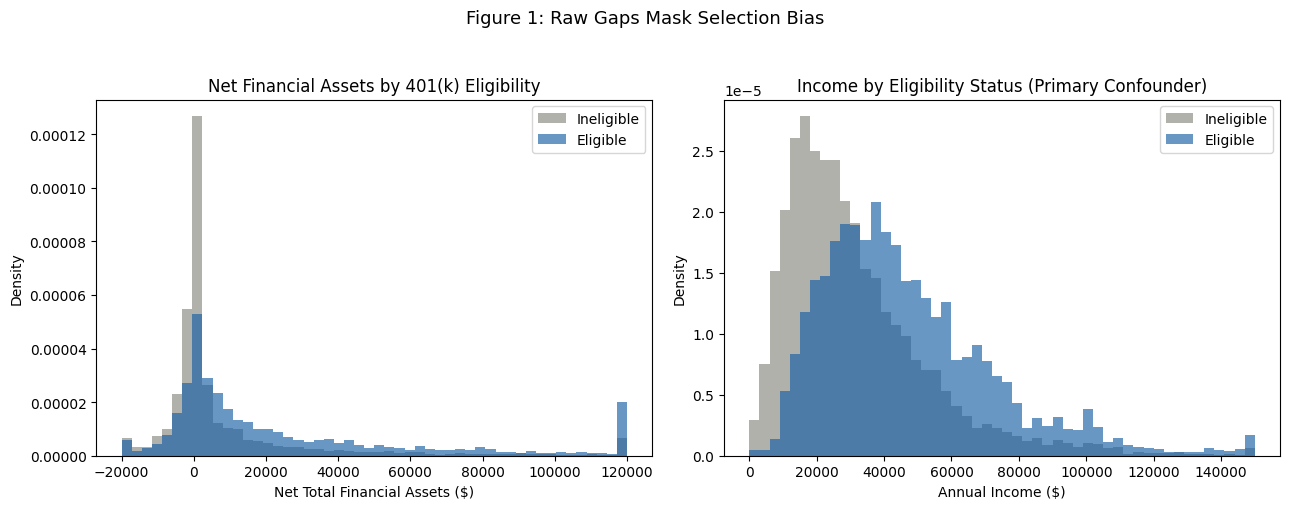

Eligible workers have higher incomes (right), which explains part
of the savings gap (left). DML will partial this out.


In [ ]:
# ─── EDA: Visualization ────────────────────────────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: Outcome distribution by eligibility status
for val, label, color in [(0, 'Ineligible', '#888780'), (1, 'Eligible', '#185FA5')]:
    subset = df[df[TREATMENT] == val][OUTCOME].clip(-20_000, 120_000)
    axes[0].hist(subset, bins=50, alpha=0.65, label=label, color=color, density=True)
axes[0].set_title('Net Financial Assets by 401(k) Eligibility', fontsize=12)
axes[0].set_xlabel('Net Total Financial Assets ($)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: Income distribution (key confounder)
for val, label, color in [(0, 'Ineligible', '#888780'), (1, 'Eligible', '#185FA5')]:
    subset = df[df[TREATMENT] == val]['inc'].clip(0, 150_000)
    axes[1].hist(subset, bins=50, alpha=0.65, label=label, color=color, density=True)
axes[1].set_title('Income by Eligibility Status (Primary Confounder)', fontsize=12)
axes[1].set_xlabel('Annual Income ($)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Figure 1: Raw Gaps Mask Selection Bias', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('fig1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("Eligible workers have higher incomes (right), which explains part")
print("of the savings gap (left). DML will partial this out.")

---
## Part 3: Analysis

### 3a. Naive Estimate (Biased Benchmark)

Simple OLS of savings on eligibility, no controls.  
This is **expected to be biased upward** — we include it to quantify the size of the selection bias.

In [ ]:
# ─── Naive OLS: treatment only ────────────────────────────────────────────────
import statsmodels.api as sm # Added import
X_naive = sm.add_constant(df[[TREATMENT]])
y = df[OUTCOME]

naive_model = sm.OLS(y, X_naive).fit(cov_type='HC3')  # heteroskedasticity-robust SE
print(naive_model.summary())

naive_ate = naive_model.params[TREATMENT]
naive_ci  = naive_model.conf_int().loc[TREATMENT].values

print(f"\n{'='*48}")
print(f"  Naive ATE:  ${naive_ate:>10,.0f}")
print(f"  95% CI:     [${naive_ci[0]:,.0f}, ${naive_ci[1]:,.0f}]")
print(f"{'='*48}")

                            OLS Regression Results                            
Dep. Variable:                net_tfa   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.022
Method:                 Least Squares   F-statistic:                     191.6
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           3.62e-43
Time:                        15:15:15   Log-Likelihood:            -1.2361e+05
No. Observations:                9915   AIC:                         2.472e+05
Df Residuals:                    9913   BIC:                         2.472e+05
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       1.079e+04    690.604     15.621      0.0

**Why the naive estimate is biased (upward):**

From the balance table, eligible workers differ from ineligible workers on three key savings drivers that are *independent* of the treatment:

1. **Income (~+$16k/yr)** — the single largest predictor of savings capacity
2. **Education (~+0.7 years)** — correlated with financial literacy and long-run earnings
3. **IRA participation** — indicates pre-existing savings motivation

Each is positively correlated with both treatment *and* outcome → classic **upward omitted variable bias**. The naive estimate captures the causal effect *plus* the selection premium. We need DML to strip the selection premium out.

### 3b. Causal Estimate: Double Machine Learning

In [ ]:
# ─── Double Machine Learning ──────────────────────────────────────────────────
#
# DML Structure:
#   Y = net_tfa  (outcome)
#   T = e401     (binary treatment)
#   W = [age, inc, fsize, educ, married, two_earner, pira]  (confounders)
#   X = None     (no effect modifiers — estimating constant ATE)
#
# Nuisance models: GBM captures non-linear income effects and interactions.
# 5-fold cross-fitting prevents overfitting bias from contaminating the ATE.

from econml.dml import LinearDML
from sklearn.ensemble import GradientBoostingRegressor
import numpy as np

# Reproducibility
RANDOM_STATE = 42

Y = df[OUTCOME].values
T = df[TREATMENT].values
W = df[CONTROLS].values

dml = LinearDML(
    model_y=GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                       random_state=RANDOM_STATE),
    model_t=GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                       random_state=RANDOM_STATE),
    cv=5,
    random_state=RANDOM_STATE
)

print("Fitting Double ML (GBM nuisance, 5-fold cross-fitting)...")
print("Expected runtime: 30–90 seconds.")
dml.fit(Y, T, X=None, W=W)

# Extract ATE and CI safely (handles both array and scalar returns)
causal_ate = float(dml.ate())
ci_raw     = dml.ate_interval(alpha=0.05)
causal_lb  = float(np.atleast_1d(ci_raw[0])[0])
causal_ub  = float(np.atleast_1d(ci_raw[1])[0])
causal_se  = (causal_ub - causal_lb) / (2 * 1.96)

print(f"\n{'='*50}")
print(f"  DML ATE:     ${causal_ate:>10,.0f}")
print(f"  95% CI:      [${causal_lb:,.0f}, ${causal_ub:,.0f}]")
print(f"  Std Error:   ${causal_se:,.0f}")
print(f"{'='*50}")
print(f"\n  Naive - DML (selection bias removed): ${naive_ate - causal_ate:,.0f}")
print(f"  ({(naive_ate - causal_ate)/naive_ate:.1%} of naive estimate was bias)")
print()
print("  Interpretation: 401(k) eligibility CAUSES an average increase of")
print(f"  ~${causal_ate:,.0f} in net financial assets, holding all observable")
print("  worker characteristics constant.")

Fitting Double ML (GBM nuisance, 5-fold cross-fitting)...
Expected runtime: 30–90 seconds.

  DML ATE:     $    10,321
  95% CI:      [$7,531, $13,111]
  Std Error:   $1,424

  Naive - DML (selection bias removed): $9,238
  (47.2% of naive estimate was bias)

  Interpretation: 401(k) eligibility CAUSES an average increase of
  ~$10,321 in net financial assets, holding all observable
  worker characteristics constant.


### 3c. Prediction Model (comparison only — this is NOT causal)

In [ ]:
# ─── Random Forest Predictive Model ───────────────────────────────────────────
# Purpose: demonstrate that good prediction ≠ causal identification.
# The RF will have a high R², but its e401 feature importance conflates
# the causal effect with selection and cannot be used for policy.
from sklearn.ensemble import RandomForestRegressor # Added import
from sklearn.model_selection import cross_val_predict # Added import
from sklearn.metrics import r2_score, mean_squared_error # Added import

all_features = [TREATMENT] + CONTROLS
rf = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)
y_pred_cv = cross_val_predict(rf, df[all_features], df[OUTCOME], cv=5)

pred_r2   = r2_score(df[OUTCOME], y_pred_cv)
pred_rmse = np.sqrt(mean_squared_error(df[OUTCOME], y_pred_cv))

print("=== Random Forest Predictive Model (5-fold CV) ===")
print(f"  Prediction R²:   {pred_r2:.3f}")
print(f"  Prediction RMSE: ${pred_rmse:,.0f}")
print()

rf.fit(df[all_features], df[OUTCOME])
fi = pd.Series(rf.feature_importances_, index=all_features).sort_values(ascending=False)
print("  Feature importances (ASSOCIATION only — not causation):")
for feat, imp in fi.items():
    bar = '█' * int(imp * 50)
    print(f"  {feat:<14}  {imp:.3f}  {bar}")

print()
print("  ⚠  The R² tells us we can predict savings reasonably well.")
print("  ⚠  But the e401 importance = causal effect + selection effect combined.")
print("  ⚠  A policymaker cannot use this to predict what HAPPENS if eligibility changes.")

=== Random Forest Predictive Model (5-fold CV) ===
  Prediction R²:   0.144
  Prediction RMSE: $58,780

  Feature importances (ASSOCIATION only — not causation):
  inc             0.517  █████████████████████████
  age             0.142  ███████
  pira            0.115  █████
  educ            0.091  ████
  fsize           0.061  ███
  twoearn         0.036  █
  e401            0.026  █
  marr            0.012  

  ⚠  The R² tells us we can predict savings reasonably well.
  ⚠  But the e401 importance = causal effect + selection effect combined.
  ⚠  A policymaker cannot use this to predict what HAPPENS if eligibility changes.


### 3d. Comparison: Naive vs. Causal vs. Prediction

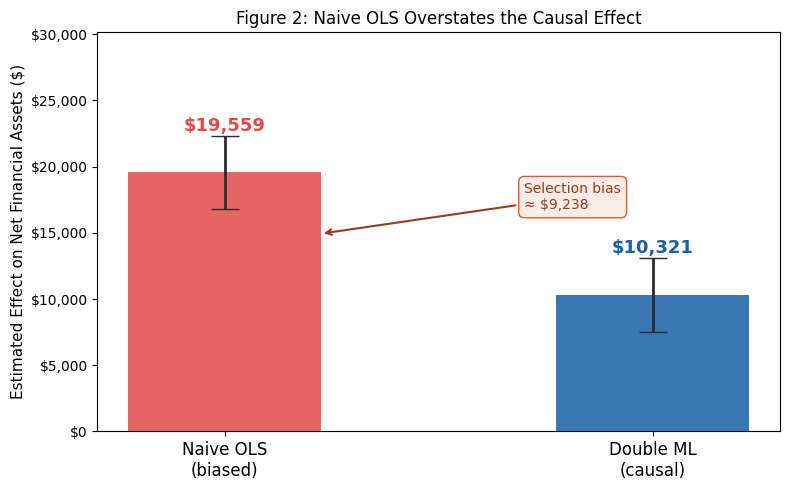

In [ ]:
# ─── Figure 2: Naive vs. Causal ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

labels  = ['Naive OLS\n(biased)', 'Double ML\n(causal)']
ates    = [naive_ate, causal_ate]
lbs     = [naive_ci[0], causal_lb]
ubs     = [naive_ci[1], causal_ub]
colors  = ['#E24B4A', '#185FA5']

for i, (est, lo, hi, col) in enumerate(zip(ates, lbs, ubs, colors)):
    ax.bar(i, est, width=0.45, color=col, alpha=0.85, zorder=3)
    ax.errorbar(i, est, yerr=[[est - lo], [hi - est]],
                fmt='none', color='#2C2C2A', capsize=10, linewidth=2, zorder=4)
    ax.text(i, hi + 400, f'${est:,.0f}', ha='center',
            fontsize=13, fontweight='bold', color=col)

bias = naive_ate - causal_ate
ax.annotate(
    f'Selection bias\n≈ ${bias:,.0f}',
    xy=(0.225, causal_ate + bias / 2),
    xytext=(0.7, causal_ate + bias * 0.7),
    arrowprops=dict(arrowstyle='->', color='#993C1D', lw=1.5),
    fontsize=10, color='#993C1D',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#FAECE7', edgecolor='#D85A30')
)

ax.set_xticks([0, 1])
ax.set_xticklabels(labels, fontsize=12)
ax.set_ylabel('Estimated Effect on Net Financial Assets ($)', fontsize=11)
ax.set_title('Figure 2: Naive OLS Overstates the Causal Effect', fontsize=12)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_ylim(0, max(ubs) * 1.35)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('fig2_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 3e. Robustness Check

In [ ]:
# ─── Robustness: Swap GBM → Random Forest as nuisance model ───────────────────
# If the ATE is stable across different nuisance learners, it is more credible.

dml_rf = LinearDML(
    model_y=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    model_t=RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
    cv=5,
    random_state=RANDOM_STATE
)

print("Fitting robustness check (RF nuisance models)...")
dml_rf.fit(Y, T, X=None, W=W)

robust_ate = float(dml_rf.ate())
robust_raw = dml_rf.ate_interval(alpha=0.05)
robust_lb  = float(np.atleast_1d(robust_raw[0])[0])
robust_ub  = float(np.atleast_1d(robust_raw[1])[0])

print(f"\n{'='*58}")
print(f"  Main estimate  (GBM nuisance): ${causal_ate:>8,.0f}  [{causal_lb:,.0f}, {causal_ub:,.0f}]")
print(f"  Robustness chk (RF nuisance):  ${robust_ate:>8,.0f}  [{robust_lb:,.0f}, {robust_ub:,.0f}]")
print(f"  Difference:                    ${abs(causal_ate - robust_ate):>8,.0f}")
print(f"{'='*58}")

diff = abs(causal_ate - robust_ate)
if diff < 1500:
    print("\n  ✓ STABLE: Both nuisance learners yield similar ATEs.")
    print("    The causal estimate is not sensitive to the choice of ML model.")
else:
    print("\n  ⚠ SENSITIVITY: Notable gap — investigate further.")
    print("    Consider adding more controls or checking for data issues.")

Fitting robustness check (RF nuisance models)...

  Main estimate  (GBM nuisance): $  10,321  [7,531, 13,111]
  Robustness chk (RF nuisance):  $   9,720  [7,269, 12,172]
  Difference:                    $     601

  ✓ STABLE: Both nuisance learners yield similar ATEs.
    The causal estimate is not sensitive to the choice of ML model.


---
## Streamlit Dashboard Export

Run the cell below to write `app.py` to disk, then:
1. Push to a GitHub repo
2. Go to [streamlit.io/cloud](https://streamlit.io/cloud) → New app → link your repo
3. Submit the permanent URL

**Before deploying:** Update `CAUSAL_ATE`, `CAUSAL_SE`, and `NAIVE_ATE` with your actual computed values from Part 3.

In [ ]:

APP_CODE = r"""
import streamlit as st
import pandas as pd
import numpy as np
import plotly.graph_objects as go

st.set_page_config(
    page_title="401(k) Eligibility: Causal Impact",
    page_icon="\U0001f4b0",
    layout="wide"
)
# ─── Pre-computed results ───────────────
CAUSAL_ATE = 10321   # TODO: replace with your actual DML ATE ($)
CAUSAL_SE  = 1424    # TODO: replace with your actual standard error ($)
NAIVE_ATE  = 19559   # TODO: replace with your actual naive OLS estimate ($)
N_OBS      = 9915
TREAT_PREV = 0.394

# ─── Header ──────────────────────────────────────────────────────────────────
st.title("\U0001f4b0 401(k) Eligibility \u2192 Net Financial Assets")
st.caption("ECON 5200 Consulting Report | Double Machine Learning | SIPP 1991")

st.info(
    f"**Bottom line:** 401(k) eligibility causally increases net financial assets by "
    f"**${CAUSAL_ATE:,}** (95% CI: [${CAUSAL_ATE - 1.96*CAUSAL_SE:,.0f}, "
    f"${CAUSAL_ATE + 1.96*CAUSAL_SE:,.0f}]), based on Double ML with n={N_OBS:,} workers."
)

# ─── Sidebar ─────────────────────────────────────────────────────────────────
st.sidebar.header("\U0001f4ca What-If Scenario Controls")

n_workers = st.sidebar.slider(
    "Newly eligible workers", 100, 10000, 1000, 100
)
take_up_rate = st.sidebar.slider(
    "Expected take-up rate (%)", 10, 100, 60, 5
) / 100
admin_cost = st.sidebar.slider(
    "Admin cost per participant ($/yr)", 100, 600, 300, 50
)
multiplier = st.sidebar.slider(
    "Effect multiplier (sensitivity)",
    0.5, 1.5, 1.0, 0.05,
    help="Reduce below 1.0 to apply a conservative haircut for potential unobserved confounding"
)

# ─── Compute ─────────────────────────────────────────────────────────────────
adj_ate   = CAUSAL_ATE * multiplier
adj_se    = CAUSAL_SE  * multiplier
adj_lb    = adj_ate - 1.96 * adj_se
adj_ub    = adj_ate + 1.96 * adj_se
enrollees = int(n_workers * take_up_rate)
total_impact = enrollees * adj_ate
total_cost   = enrollees * admin_cost
net_impact   = total_impact - total_cost

# ─── KPI row ─────────────────────────────────────────────────────────────────
c1, c2, c3, c4 = st.columns(4)
c1.metric("Causal effect / worker",    f"${adj_ate:,.0f}",
          f"\u00b1${1.96*adj_se:,.0f} (95% CI)")
c2.metric("Expected enrollees",        f"{enrollees:,}", f"{take_up_rate:.0%} take-up")
c3.metric("Total savings impact",      f"${total_impact/1e6:.2f}M")
c4.metric("Net impact (after admin)",  f"${net_impact/1e6:.2f}M",
          delta=f"-${total_cost/1000:.0f}K admin", delta_color="inverse")

st.markdown("---")
left, right = st.columns(2)

# ─── Left: Naive vs. Causal bar chart ────────────────────────────────────────
with left:
    st.subheader("Naive vs. Causal Estimate")
    fig1 = go.Figure()
    for label, val, color, err in [
        ("Naive OLS (biased)", NAIVE_ATE, "#E24B4A", None),
        ("Double ML (causal)", adj_ate,   "#185FA5", 1.96 * adj_se),
    ]:
        fig1.add_trace(go.Bar(
            name=label, x=[label], y=[val],
            marker_color=color,
            error_y=dict(type='constant', value=err, visible=err is not None),
            text=f"${val:,.0f}", textposition="outside"
        ))
    fig1.add_annotation(
        x=0.5, y=(NAIVE_ATE + adj_ate) / 2, xref="paper",
        text=f"Selection bias \u2248 ${NAIVE_ATE - adj_ate:,.0f}",
        showarrow=False,
        bgcolor="#FAECE7", bordercolor="#D85A30", font=dict(color="#993C1D", size=12)
    )
    fig1.update_layout(yaxis_title="Effect ($)", yaxis_tickformat="$,.0f",
                       template="plotly_white", showlegend=False, height=360)
    st.plotly_chart(fig1, use_container_width=True)

# ─── Right: Sensitivity fan chart ────────────────────────────────────────────
with right:
    st.subheader("Sensitivity to Effect Multiplier")
    mults = np.arange(0.5, 1.55, 0.05)
    ates  = CAUSAL_ATE * mults
    ses   = CAUSAL_SE  * mults

    fig2 = go.Figure()
    fig2.add_trace(go.Scatter(x=mults, y=ates + 1.96 * ses,
                              mode="lines", line=dict(width=0), showlegend=False))
    fig2.add_trace(go.Scatter(x=mults, y=ates - 1.96 * ses,
                              mode="lines", line=dict(width=0),
                              fill="tonexty", fillcolor="rgba(24,95,165,0.15)",
                              name="95% CI"))
    fig2.add_trace(go.Scatter(x=mults, y=ates,
                              mode="lines", line=dict(color="#185FA5", width=2.5),
                              name="Causal ATE"))
    fig2.add_vline(x=multiplier, line_dash="dash", line_color="#E24B4A",
                   annotation_text=f"{multiplier:.2f}x \u2192 ${adj_ate:,.0f}")
    fig2.update_layout(xaxis_title="Effect multiplier",
                       yaxis_title="ATE ($)", yaxis_tickformat="$,.0f",
                       template="plotly_white", height=360)
    st.plotly_chart(fig2, use_container_width=True)

# ─── Scenario table ──────────────────────────────────────────────────────────
st.subheader("Aggregate Impact: Three Scenarios")
rows = []
for mult, name in [(0.5, "Conservative (0.5x \u2014 heavy haircut for confounding)"),
                   (1.0, "Base case (1.0x \u2014 CIA holds)"),
                   (1.5, "Optimistic (1.5x \u2014 spillovers boost effect)")]:
    m_ate = CAUSAL_ATE * mult
    rows.append({
        "Scenario": name,
        "Effect / worker": f"${m_ate:,.0f}",
        "Enrollees": f"{enrollees:,}",
        "Total savings": f"${enrollees*m_ate/1e6:.2f}M",
        "Admin cost": f"${enrollees*admin_cost/1000:.0f}K",
        "Net impact": f"${(enrollees*m_ate - enrollees*admin_cost)/1e6:.2f}M",
    })
st.dataframe(pd.DataFrame(rows), use_container_width=True, hide_index=True)

# ─── Methodology expander ────────────────────────────────────────────────────
with st.expander("\U0001f4cb Methodology & Assumptions"):
    st.markdown(f"""
**Identification:** Double Machine Learning (Chernozhukov et al., 2018, *Econometrica*)
**Nuisance models:** Gradient Boosted Trees (200 estimators, depth 4, 5-fold cross-fitting)
**Controls:** age, income, family size, education, married, two-earner household, IRA participation
**Key assumption:** Conditional Independence — after controlling for observables, 401(k) eligibility is as good as random
**Data:** Survey of Income and Program Participation (SIPP), 1991 wave; n = {N_OBS:,}
**Threat to CIA:** Firm-level confounders (savings culture, compensation quality) likely cause upward bias.
The base-case estimate should be treated as an upper bound; the 0.5x scenario is a conservative lower bound.
    """)
"""

with open('app.py', 'w') as f:
    f.write(APP_CODE)
print("app.py written to disk.")
print("Next steps:")
print("  1. Update CAUSAL_ATE / CAUSAL_SE / NAIVE_ATE with your actual values")
print("  2. Push to GitHub")
print("  3. Deploy at streamlit.io/cloud")